In [1]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.getOrCreate()

In [2]:
df = spark.read.csv("hdfs://localhost:9000//data/countries.csv", header=True, inferSchema=True)

In [3]:
df.printSchema()

root
 |-- Country: string (nullable = true)
 |-- Region: string (nullable = true)
 |-- Population: integer (nullable = true)
 |-- Area (sq. mi.): integer (nullable = true)
 |-- Pop. Density (per sq. mi.): string (nullable = true)
 |-- Coastline (coast/area ratio): string (nullable = true)
 |-- Net migration: string (nullable = true)
 |-- Infant mortality (per 1000 births): string (nullable = true)
 |-- GDP ($ per capita): integer (nullable = true)
 |-- Literacy (%): string (nullable = true)
 |-- Phones (per 1000): string (nullable = true)
 |-- Arable (%): string (nullable = true)
 |-- Crops (%): string (nullable = true)
 |-- Other (%): string (nullable = true)
 |-- Climate: string (nullable = true)
 |-- Birthrate: string (nullable = true)
 |-- Deathrate: string (nullable = true)
 |-- Agriculture: string (nullable = true)
 |-- Industry: string (nullable = true)
 |-- Service: string (nullable = true)



In [4]:
df.show(5)

+--------------+--------------------+----------+--------------+--------------------------+----------------------------+-------------+----------------------------------+------------------+------------+-----------------+----------+---------+---------+-------+---------+---------+-----------+--------+-------+
|       Country|              Region|Population|Area (sq. mi.)|Pop. Density (per sq. mi.)|Coastline (coast/area ratio)|Net migration|Infant mortality (per 1000 births)|GDP ($ per capita)|Literacy (%)|Phones (per 1000)|Arable (%)|Crops (%)|Other (%)|Climate|Birthrate|Deathrate|Agriculture|Industry|Service|
+--------------+--------------------+----------+--------------+--------------------------+----------------------------+-------------+----------------------------------+------------------+------------+-----------------+----------+---------+---------+-------+---------+---------+-----------+--------+-------+
|   Afghanistan|ASIA (EX. NEAR EAST)|  31056997|        647500|                

In [5]:
df.createOrReplaceTempView("countries")

1. Hiển thị toàn bộ thông tin của một quốc gia khi biết tên quốc gia

In [6]:
spark.sql("select * from countries where country = 'Vietnam'").show()

+-------+--------------------+----------+--------------+--------------------------+----------------------------+-------------+----------------------------------+------------------+------------+-----------------+----------+---------+---------+-------+---------+---------+-----------+--------+-------+
|Country|              Region|Population|Area (sq. mi.)|Pop. Density (per sq. mi.)|Coastline (coast/area ratio)|Net migration|Infant mortality (per 1000 births)|GDP ($ per capita)|Literacy (%)|Phones (per 1000)|Arable (%)|Crops (%)|Other (%)|Climate|Birthrate|Deathrate|Agriculture|Industry|Service|
+-------+--------------------+----------+--------------+--------------------------+----------------------------+-------------+----------------------------------+------------------+------------+-----------------+----------+---------+---------+-------+---------+---------+-----------+--------+-------+
|Vietnam|ASIA (EX. NEAR EAST)|  84402966|        329560|                     256,1|                 

2. Liệt kê các quốc gia thuộc vùng “ASIA (EX. NEAR EAST)”

In [7]:
spark.sql("select * from countries where region = 'ASIA (EX. NEAR EAST)'").show()

+-------------+--------------------+----------+--------------+--------------------------+----------------------------+-------------+----------------------------------+------------------+------------+-----------------+----------+---------+---------+-------+---------+---------+-----------+--------+-------+
|      Country|              Region|Population|Area (sq. mi.)|Pop. Density (per sq. mi.)|Coastline (coast/area ratio)|Net migration|Infant mortality (per 1000 births)|GDP ($ per capita)|Literacy (%)|Phones (per 1000)|Arable (%)|Crops (%)|Other (%)|Climate|Birthrate|Deathrate|Agriculture|Industry|Service|
+-------------+--------------------+----------+--------------+--------------------------+----------------------------+-------------+----------------------------------+------------------+------------+-----------------+----------+---------+---------+-------+---------+---------+-----------+--------+-------+
|  Afghanistan|ASIA (EX. NEAR EAST)|  31056997|        647500|                    

3. Liệt kê 5 quốc gia có dân số đông nhất

In [8]:
spark.sql("select * from countries order by population desc limit 5").show()

+-------------+--------------------+----------+--------------+--------------------------+----------------------------+-------------+----------------------------------+------------------+------------+-----------------+----------+---------+---------+-------+---------+---------+-----------+--------+-------+
|      Country|              Region|Population|Area (sq. mi.)|Pop. Density (per sq. mi.)|Coastline (coast/area ratio)|Net migration|Infant mortality (per 1000 births)|GDP ($ per capita)|Literacy (%)|Phones (per 1000)|Arable (%)|Crops (%)|Other (%)|Climate|Birthrate|Deathrate|Agriculture|Industry|Service|
+-------------+--------------------+----------+--------------+--------------------------+----------------------------+-------------+----------------------------------+------------------+------------+-----------------+----------+---------+---------+-------+---------+---------+-----------+--------+-------+
|        China|ASIA (EX. NEAR EAST)|1313973713|       9596960|                    

4. Liệt kê 5 quốc gia có diện tích nhỏ nhất / lớn nhất

In [9]:
spark.sql("select * from countries order by `area (sq. mi.)` desc limit 5").show()

+-------------+--------------------+----------+--------------+--------------------------+----------------------------+-------------+----------------------------------+------------------+------------+-----------------+----------+---------+---------+-------+---------+---------+-----------+--------+-------+
|      Country|              Region|Population|Area (sq. mi.)|Pop. Density (per sq. mi.)|Coastline (coast/area ratio)|Net migration|Infant mortality (per 1000 births)|GDP ($ per capita)|Literacy (%)|Phones (per 1000)|Arable (%)|Crops (%)|Other (%)|Climate|Birthrate|Deathrate|Agriculture|Industry|Service|
+-------------+--------------------+----------+--------------+--------------------------+----------------------------+-------------+----------------------------------+------------------+------------+-----------------+----------+---------+---------+-------+---------+---------+-----------+--------+-------+
|       Russia| C.W. OF IND. STATES| 142893540|      17075200|                    

5. Liệt kê 5 quốc gia có mật độ dân số nhỏ nhất / lớn nhất
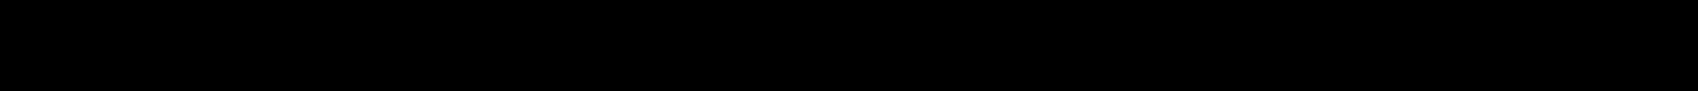

In [10]:
spark.sql("select country, `pop. density (per sq. mi.)` from countries order by cast(replace(`pop. density (per sq. mi.)`,',','.') as float) limit 5").show()

+--------------+--------------------------+
|       country|pop. density (per sq. mi.)|
+--------------+--------------------------+
|     Greenland|                       0,0|
|Western Sahara|                       1,0|
|      Mongolia|                       1,8|
| French Guiana|                       2,2|
|       Namibia|                       2,5|
+--------------+--------------------------+



6. Liệt kê các quốc gia thuộc vùng “NEAR EAST” có dân số lớn hơn 15 triệu

In [11]:
spark.sql("select country, region, population from countries where region = 'NEAR EAST' and population > 15000000").show()

+------------+---------+----------+
|     country|   region|population|
+------------+---------+----------+
|        Iraq|NEAR EAST|  26783383|
|Saudi Arabia|NEAR EAST|  27019731|
|       Syria|NEAR EAST|  18881361|
|      Turkey|NEAR EAST|  70413958|
|       Yemen|NEAR EAST|  21456188|
+------------+---------+----------+



7. Liệt kê 5 quốc gia châu Phi có tỷ lệ trẻ em tử vong (Infant mortality (per 1000 births)) cao nhất.

In [12]:
df.groupBy('region').count().show()

+--------------------+-----+
|              region|count|
+--------------------+-----+
| C.W. OF IND. STATES|   12|
|      EASTERN EUROPE|   12|
|    NORTHERN AMERICA|    5|
|ASIA (EX. NEAR EAST)|   28|
|             OCEANIA|   21|
|      WESTERN EUROPE|   28|
|           NEAR EAST|   16|
|  SUB-SAHARAN AFRICA|   51|
|             BALTICS|    3|
| LATIN AMER. & CARIB|   45|
|     NORTHERN AFRICA|    6|
+--------------------+-----+



In [13]:
spark.sql("select country, region, `infant mortality (per 1000 births)` from countries where region in ('SUB-SAHARAN AFRICA', 'NORTHERN AFRICA') order by cast(replace(`infant mortality (per 1000 births)`,',','.') as float) desc limit 5").show()

+------------+------------------+----------------------------------+
|     country|            region|infant mortality (per 1000 births)|
+------------+------------------+----------------------------------+
|      Angola|SUB-SAHARAN AFRICA|                            191,19|
|Sierra Leone|SUB-SAHARAN AFRICA|                            143,64|
|  Mozambique|SUB-SAHARAN AFRICA|                            130,79|
|     Liberia|SUB-SAHARAN AFRICA|                            128,87|
|       Niger|SUB-SAHARAN AFRICA|                            121,69|
+------------+------------------+----------------------------------+



8. Hiển thị khu vực có trung bình GDP cao nhất

In [14]:
spark.sql("select region, AVG(`GDP ($ per capita)`) as average_gdp from countries group by region order by average_gdp desc limit 1").show()

+--------------+------------------+
|        region|       average_gdp|
+--------------+------------------+
|WESTERN EUROPE|27046.428571428572|
+--------------+------------------+



9.1. Top 10 quốc gia có tỷ lệ biết chữ (Literacy (%)) cao nhất nhưng lại có số lượng điện thoại trên 1000 dân (Phones (per 1000)) thấp nhất

In [15]:
spark.sql("select country, `literacy (%)`, `Phones (per 1000)` from countries order by cast(replace(`literacy (%)`,',','.') as float) desc, cast(replace(`phones (per 1000)`,',','.') as float) limit 10").show()

+--------------+------------+-----------------+
|       country|literacy (%)|Phones (per 1000)|
+--------------+------------+-----------------+
|       Finland|       100,0|            405,3|
|        Norway|       100,0|            461,7|
|       Andorra|       100,0|            497,2|
|    Luxembourg|       100,0|            515,4|
|     Australia|       100,0|            565,5|
| Liechtenstein|       100,0|            585,5|
|       Denmark|       100,0|            614,6|
|Czech Republic|        99,9|            314,3|
|       Iceland|        99,9|            647,7|
|        Poland|        99,8|            306,3|
+--------------+------------+-----------------+



9.2. Region nào có tỷ lệ đất canh tác (Arable (%)) trung bình cao nhất, và GDP trung bình của khu vực đó là bao nhiêu

In [21]:
spark.sql("select region, avg(cast(replace(`Arable (%)`,',','.') as float)) as avg_arable, avg(`GDP ($ per capita)`) as avg_gdp from countries group by region order by avg_arable desc limit 1").show()

+--------------+------------------+-----------------+
|        region|        avg_arable|          avg_gdp|
+--------------+------------------+-----------------+
|EASTERN EUROPE|30.982499917348225|9808.333333333334|
+--------------+------------------+-----------------+



9.3. Trong mỗi khu vực (Region), hãy tìm quốc gia có tỷ lệ tử vong ở trẻ em (Infant mortality) cao nhất. Liệu quốc gia đó có phải là quốc gia có GDP thấp nhất trong vùng đó hay không

In [17]:
spark.sql("""WITH CleanData AS (
    SELECT
        TRIM(Region) as Region,
        Country,
        CAST(REPLACE(`Infant mortality (per 1000 births)`, ',', '.') AS DOUBLE) as Infant_Mortality,
        CAST(`GDP ($ per capita)` AS INT) as GDP
    FROM countries
),
RankedData AS (
    SELECT *,
        RANK() OVER (PARTITION BY Region ORDER BY Infant_Mortality DESC) as Mortality_Rank,
        RANK() OVER (PARTITION BY Region ORDER BY GDP ASC) as GDP_Rank
    FROM CleanData
)

SELECT
    Region,
    Country,
    Infant_Mortality,
    GDP,
    CASE WHEN GDP_Rank = 1 THEN 'DUNG (GDP thap nhat)' ELSE 'SAI (Khong phai GDP thap nhat)' END as Is_Lowest_GDP
FROM RankedData
WHERE Mortality_Rank = 1
ORDER BY Region;
          """).show()

+--------------------+-------------+----------------+-----+--------------------+
|              Region|      Country|Infant_Mortality|  GDP|       Is_Lowest_GDP|
+--------------------+-------------+----------------+-----+--------------------+
|ASIA (EX. NEAR EAST)|  Afghanistan|          163.07|  700|SAI (Khong phai G...|
|             BALTICS|       Latvia|            9.55|10200|DUNG (GDP thap nhat)|
| C.W. OF IND. STATES|   Tajikistan|          110.76| 1000|DUNG (GDP thap nhat)|
|      EASTERN EUROPE|      Romania|           26.43| 7000|SAI (Khong phai G...|
| LATIN AMER. & CARIB|        Haiti|           73.45| 1600|DUNG (GDP thap nhat)|
|           NEAR EAST|        Yemen|            61.5|  800|SAI (Khong phai G...|
|     NORTHERN AFRICA|      Morocco|           41.62| 4000|SAI (Khong phai G...|
|    NORTHERN AMERICA|    Greenland|           15.82|20000|SAI (Khong phai G...|
|             OCEANIA|      Vanuatu|           55.16| 2900|SAI (Khong phai G...|
|  SUB-SAHARAN AFRICA|      

9.4. Dựa vào 3 cột Agriculture, Industry, và Service, hãy phân loại các quốc gia thành 3 nhóm:
* "Nông nghiệp trọng điểm" (nếu Agriculture > Industry và Agriculture > Service).
* "Công nghiệp trọng điểm" (nếu Industry lớn nhất).
* "Dịch vụ trọng điểm" (nếu Service lớn nhất).

Sau đó, hãy tính GDP trung bình cho từng nhóm này.
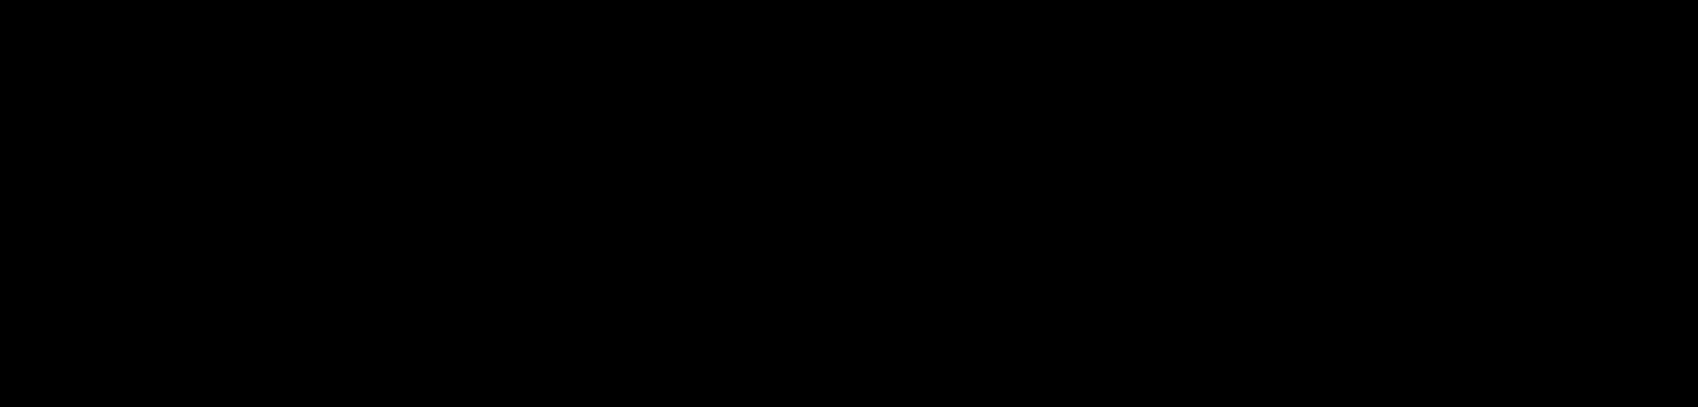

In [36]:
spark.sql("""with cleandata as(
    select
        country,
        cast(`GDP ($ per capita)` as int) as gdp,
        cast(replace(agriculture,',','.') as double) as agriculture,
        cast(replace(industry,',','.') as double) as industry,
        cast(replace(service,',','.') as double) as service,
        (case
            when (agriculture > industry) and (agriculture > service) then 'Agriculture-oriented'
            when (industry > agriculture) and (industry > service) then 'Industry-oriented'
            else 'Service-oriented'
            end
        ) as sectorfocus
    from countries
)

select
    sectorfocus,
    avg(gdp)
from cleandata
group by sectorfocus
""").show()

+--------------------+------------------+
|         sectorfocus|          avg(gdp)|
+--------------------+------------------+
|Agriculture-oriented|            1000.0|
|    Service-oriented|10803.763440860215|
|   Industry-oriented|            6400.0|
+--------------------+------------------+



9.5. Tìm các quốc gia có Net migration (tỷ lệ di cư thuần) dương (lớn hơn 0) nhưng lại có Pop. Density (mật độ dân số) thuộc top 20% cao nhất thế giới.

In [72]:
spark.sql("""with cleandata as(
    select
        country,
        cast(replace(`net migration`,',','.') as double) as net_migration,
        cast(replace(`Pop. Density (per sq. mi.)`,',','.') as double) as pop_density
    from countries
)

select * from cleandata
where net_migration > 0 and pop_density > (select percentile_cont(0.8) within group (order by pop_density) from cleandata)
order by pop_density desc
""").show()

+-----------+-------------+-----------+
|    country|net_migration|pop_density|
+-----------+-------------+-----------+
|     Monaco|         7.75|    16271.5|
|      Macau|         4.86|    16183.0|
|  Singapore|        11.53|     6482.2|
|  Hong Kong|         5.24|     6355.7|
| Gaza Strip|          1.6|     3968.8|
|      Malta|         2.07|     1266.5|
|    Bermuda|         2.49|     1241.0|
|    Bahrain|         1.05|     1050.5|
|   Guernsey|         3.84|      838.6|
|     Jersey|         2.76|      785.2|
|    Mayotte|         6.78|      538.1|
| San Marino|        10.98|      479.5|
|  West Bank|         2.98|      419.9|
|Netherlands|         2.91|      397.1|
|    Belgium|         1.23|      340.0|
|     Israel|         0.68|      305.8|
+-----------+-------------+-----------+

